## Trade Backtesting

Backtest VWAP Reclaim trades using predictions, scalp only, and oracle with 100% accuracy.

For backtesting, the following trade risk will be applied:
- Scalp Only: 750/trade
- Adaptive: 750 /trade or 1500/trade based on predictions
- Hold if Predicted: 1500/trade, skip all scalp trades
- Oracle: 750/trade or 1500/trade based on labels

In [68]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [69]:
# parameters
SCALP_RISK = 750
HOLD_RISK = 1500
SCALP_R_CAP = 0.75
HOLD_R_CAP = 2.5

In [70]:
# load predictions
df = pd.read_csv('entry_predictions.csv')
df['date_ny'] = pd.to_datetime(df['date_ny'])

# extract test only
test = df[df['split'] == 'test'].copy().reset_index(drop=True)

print(f"Test trades: {len(test)}")
print(f"Date range: {test['date_ny'].min().date()} → {test['date_ny'].max().date()}")
print(f"\nActual follow-through: {test['follow_through'].sum()} ({test['follow_through'].mean():.1%})")
print(f"Predicted Hold: {test['pred_follow_through'].sum()} ({test['pred_follow_through'].mean():.1%})")
print(f"\nSymbol distribution:")
print(test['symbol'].value_counts())

Test trades: 251
Date range: 2025-10-23 → 2026-02-27

Actual follow-through: 63 (25.1%)
Predicted Hold: 54 (21.5%)

Symbol distribution:
symbol
PLTR    58
OKLO    53
TSLA    53
NVDA    44
COIN    43
Name: count, dtype: int64


In [71]:
# simulate P&L

# scalp only trades
test['pnl_fixed'] = test['R_scalp'] * SCALP_RISK

# adaptive trades
test['mode_adaptive'] = test['pred_follow_through'].map({1: 'Hold', 0: 'Scalp'})
test['risk_adaptive'] = test['pred_follow_through'].map({1: HOLD_RISK, 0: SCALP_RISK})
test['R_adaptive'] = test.apply(
    lambda r: r['R_hold'] if r['pred_follow_through'] == 1 else r['R_scalp'], axis=1
)
test['pnl_adaptive'] = test['R_adaptive'] * test['risk_adaptive']

# hold only if model predicts follow through, else skip trade
test['pnl_hold_only'] = test.apply(
    lambda r: r['R_hold'] * HOLD_RISK if r['pred_follow_through'] == 1 else 0, axis=1
)
test['cum_pnl_hold_only'] = test['pnl_hold_only'].cumsum()

# oracle trades
test['pnl_oracle'] = test['R_oracle'] * test['risk_oracle']

# cumulative P&L
test = test.sort_values('date_ny').reset_index(drop=True)
test['cum_pnl_fixed'] = test['pnl_fixed'].cumsum()
test['cum_pnl_adaptive'] = test['pnl_adaptive'].cumsum()
test['cum_pnl_hold_only'] = test['pnl_hold_only'].cumsum()
test['cum_pnl_oracle'] = test['pnl_oracle'].cumsum()

# daily P&L
daily_equity = (
    test.groupby('date_ny')[['pnl_fixed', 'pnl_adaptive', 'pnl_hold_only', 'pnl_oracle']]
    .sum()
    .sort_index()
    .cumsum()
)
# daily equity curves
daily_equity = daily_equity.rename(columns={
    'pnl_fixed': 'cum_pnl_fixed',
    'pnl_adaptive': 'cum_pnl_adaptive',
    'pnl_hold_only': 'cum_pnl_hold_only',
    'pnl_oracle': 'cum_pnl_oracle'
})

In [72]:
# summary stats

def max_drawdown(cum_pnl_series):
    running_max = cum_pnl_series.cummax()
    drawdown = cum_pnl_series - running_max
    return drawdown.min()
    
def strategy_summary(pnl_col, r_col, label):
    pnl = test[pnl_col]
    r = test[r_col]

    total_pnl = pnl.sum()
    win_rate = (pnl > 0).mean()
    avg_r = r.mean()
    avg_win = pnl[pnl > 0].mean() if (pnl > 0).any() else 0
    avg_loss = pnl[pnl < 0].mean() if (pnl < 0).any() else 0

    # daily sharpe
    daily_pnl = test.groupby('date_ny')[pnl_col].sum()
    sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252) if daily_pnl.std() > 0 else 0

    # max drawdown
    cum_daily_pnl = daily_pnl.cumsum()
    mdd = max_drawdown(cum_daily_pnl)

    return {
        'Strategy': label,
        'Total P&L': total_pnl,
        'Win Rate': win_rate,
        'Avg R': avg_r,
        'Avg Win': avg_win,
        'Avg Loss': avg_loss,
        'Max Drawdown': mdd,
        'Daily Sharpe': sharpe
    }

results_table = pd.DataFrame([
    strategy_summary('pnl_fixed', 'R_scalp', 'Scalp Only'),
    strategy_summary('pnl_adaptive', 'R_adaptive', 'Adaptive'),
    strategy_summary('pnl_hold_only', 'R_hold', 'Hold if Predicted'),
    strategy_summary('pnl_oracle', 'R_oracle', 'Oracle')
])

results_table_display = results_table.copy()
results_table_display['Total P&L'] = results_table_display['Total P&L'].map(lambda x: f"${x:,.0f}")
results_table_display['Win Rate'] = results_table_display['Win Rate'].map(lambda x: f"{x:.1%}")
results_table_display['Avg R'] = results_table_display['Avg R'].map(lambda x: f"{x:.3f}")
results_table_display['Avg Win'] = results_table_display['Avg Win'].map(lambda x: f"${x:,.0f}")
results_table_display['Avg Loss'] = results_table_display['Avg Loss'].map(lambda x: f"${x:,.0f}")
results_table_display['Max Drawdown'] = results_table_display['Max Drawdown'].map(lambda x: f"${x:,.0f}")
results_table_display['Daily Sharpe'] = results_table_display['Daily Sharpe'].map(lambda x: f"{x:.3f}")

print("RESULTS:")
print(results_table_display)

RESULTS:
            Strategy Total P&L Win Rate   Avg R Avg Win Avg Loss Max Drawdown  \
0         Scalp Only  $-20,653    35.5%  -0.110  $1,114    $-739     $-24,028   
1           Adaptive   $27,015    36.3%   0.005  $1,828    $-871     $-18,000   
2  Hold if Predicted   $52,168    10.4%  -0.023  $3,622  $-1,500      $-7,500   
3             Oracle   $80,972    39.8%   0.151  $2,113    $-863      $-8,625   

  Daily Sharpe  
0       -2.730  
1        2.110  
2        4.908  
3        5.293  


In [73]:
# gap analysis
fixed_pnl = test['pnl_fixed'].sum()
adaptive_pnl = test['pnl_adaptive'].sum()
hold_only_pnl = test['pnl_hold_only'].sum()
oracle_pnl = test['pnl_oracle'].sum()
denom = oracle_pnl - fixed_pnl
gap_closed = 100 * (adaptive_pnl - fixed_pnl) / denom if abs(denom) > 1e-9 else np.nan

print(f"Oracle ceiling: ${oracle_pnl:>10,.0f}")
print(f"Adaptive gain: ${adaptive_pnl - fixed_pnl:>+10,.0f} vs Scalp Only")
print(f"Hold if predicted: ${hold_only_pnl - fixed_pnl:>+10,.0f} vs Scalp Only")
print(f"Gap closed: {gap_closed:.1f}%")
print(f"Hold if predicted gap closed: {(hold_only_pnl - fixed_pnl) / (oracle_pnl - fixed_pnl) * 100:.1f}%")

Oracle ceiling: $    80,972
Adaptive gain: $   +47,668 vs Scalp Only
Hold if predicted: $   +72,821 vs Scalp Only
Gap closed: 46.9%
Hold if predicted gap closed: 71.7%


The model drastically improved realized P&L on unseen data. Win Rate did not change much but because more hold trades were deployed, average win P&L jumped ~$700.

An alternative strategy after performing backtesting and P&L analysis would be to only trade VWAP Reclaim when the model predicts follow-through. 

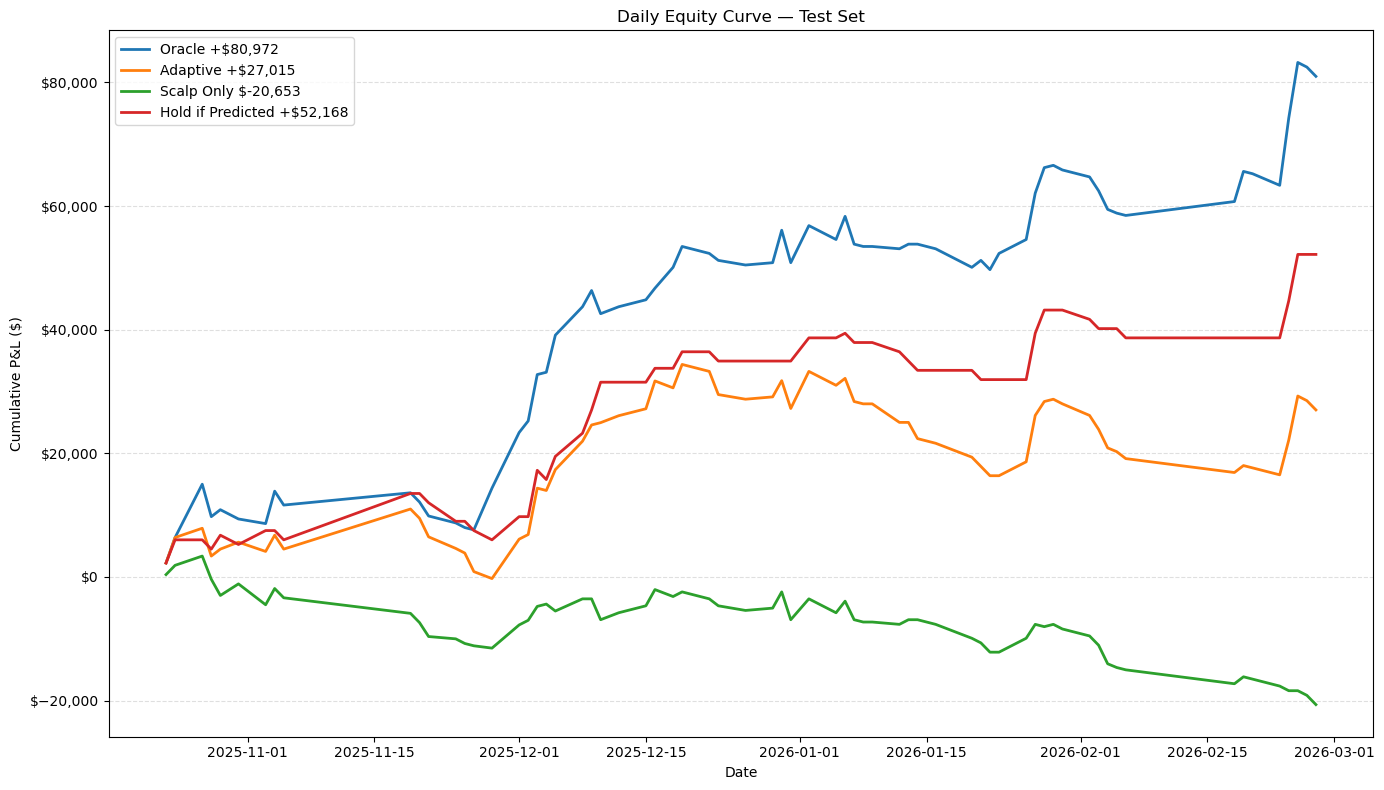

In [74]:
# daily equity curve
plt.figure(figsize=(14, 8))

plt.plot(daily_equity.index, daily_equity['cum_pnl_oracle'],
         linewidth=2, label=f"Oracle +${oracle_pnl:,.0f}")
plt.plot(daily_equity.index, daily_equity['cum_pnl_adaptive'],
         linewidth=2, label=f"Adaptive +${adaptive_pnl:,.0f}")
plt.plot(daily_equity.index, daily_equity['cum_pnl_fixed'],
         linewidth=2, label=f"Scalp Only ${fixed_pnl:,.0f}")
plt.plot(daily_equity.index, daily_equity['cum_pnl_hold_only'],
         linewidth=2, label=f"Hold if Predicted +${hold_only_pnl:,.0f}")

plt.title('Daily Equity Curve — Test Set')
plt.xlabel('Date')
plt.ylabel('Cumulative P&L ($)')
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

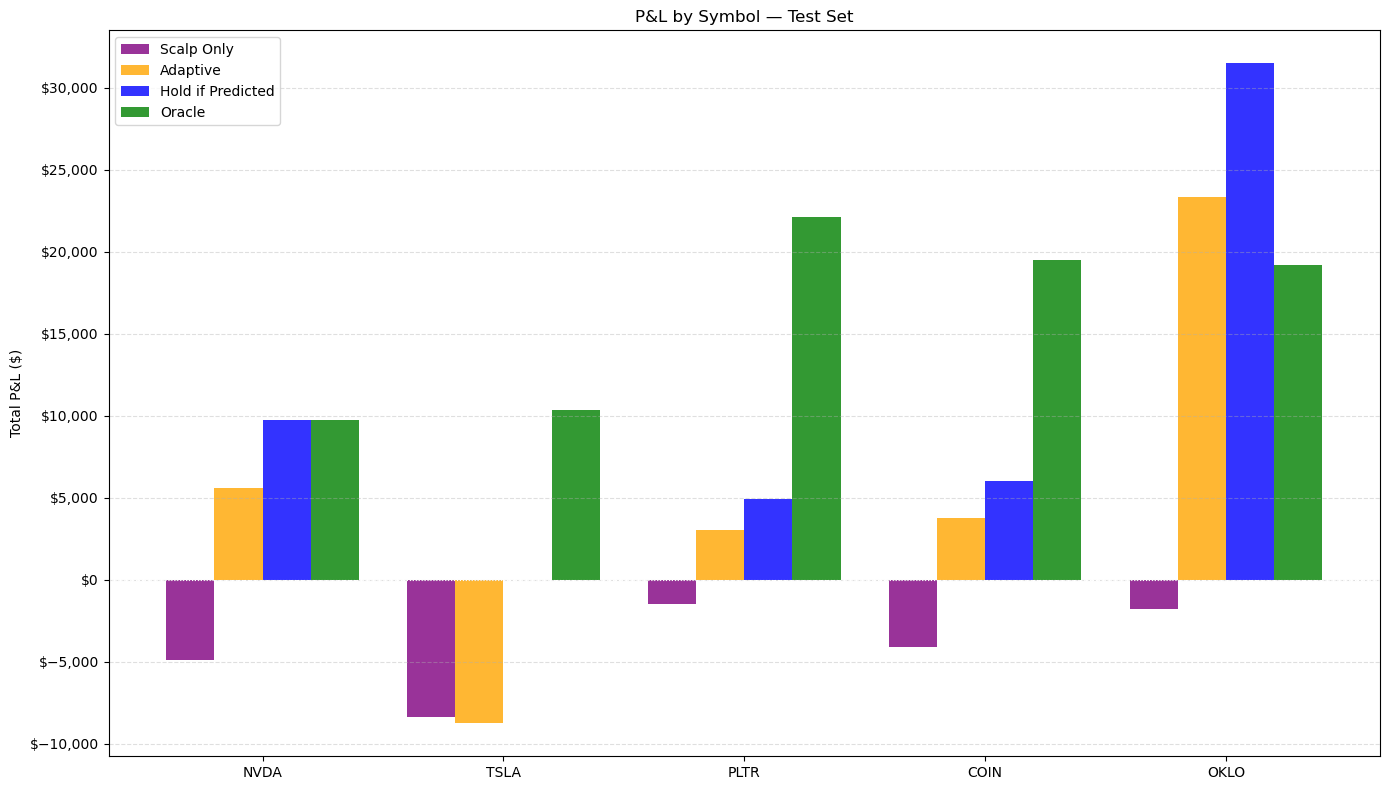

In [75]:
# P&L breakdown by stock
fig, ax = plt.subplots(figsize=(14, 8))
symbols = test['symbol'].unique()
x = np.arange(len(symbols))
width = 0.20

fixed_vals = [test[test['symbol'] == s]['pnl_fixed'].sum() for s in symbols]
adaptive_vals = [test[test['symbol'] == s]['pnl_adaptive'].sum() for s in symbols]
hold_only_vals = [test[test['symbol'] == s]['pnl_hold_only'].sum() for s in symbols]
oracle_vals = [test[test['symbol'] == s]['pnl_oracle'].sum() for s in symbols]

ax.bar(x - 1.5*width, fixed_vals, width, label='Scalp Only', color='purple', alpha=0.8)
ax.bar(x - 0.5*width, adaptive_vals, width, label='Adaptive', color='orange', alpha=0.8)
ax.bar(x + 0.5*width, hold_only_vals, width, label='Hold if Predicted', color='blue', alpha=0.8)
ax.bar(x + 1.5*width, oracle_vals, width, label='Oracle', color='green', alpha=0.8)

ax.axhline(0, color='white', linestyle=':', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(symbols)
ax.set_title('P&L by Symbol — Test Set')
ax.set_ylabel('Total P&L ($)')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:,.0f}'))
plt.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()